In [2]:
import pandas as pd
import matplotlib.pyplot as plt


csv_path = "results/train_multi_students_results.csv"

df = pd.read_csv(csv_path)

print(df.head())
print(df.columns)

   epoch  train_s1_loss  train_s1_ce  train_s1_kd  train_s1_feature  alpha  \
0      1       9.955450     7.106249     0.802971         60.008400    0.5   
1      2       3.183115     5.153750     0.632427          2.900262    0.5   
2      3       2.826113     4.717988     0.599977          1.671303    0.5   
3      4       2.624113     4.452742     0.576889          1.092978    0.5   
4      5       2.493360     4.263931     0.561201          0.807940    0.5   

   beta  gamma  temperature  
0   0.5    0.1          3.0  
1   0.5    0.1          3.0  
2   0.5    0.1          3.0  
3   0.5    0.1          3.0  
4   0.5    0.1          3.0  
Index(['epoch', 'train_s1_loss', 'train_s1_ce', 'train_s1_kd',
       'train_s1_feature', 'alpha', 'beta', 'gamma', 'temperature'],
      dtype='str')


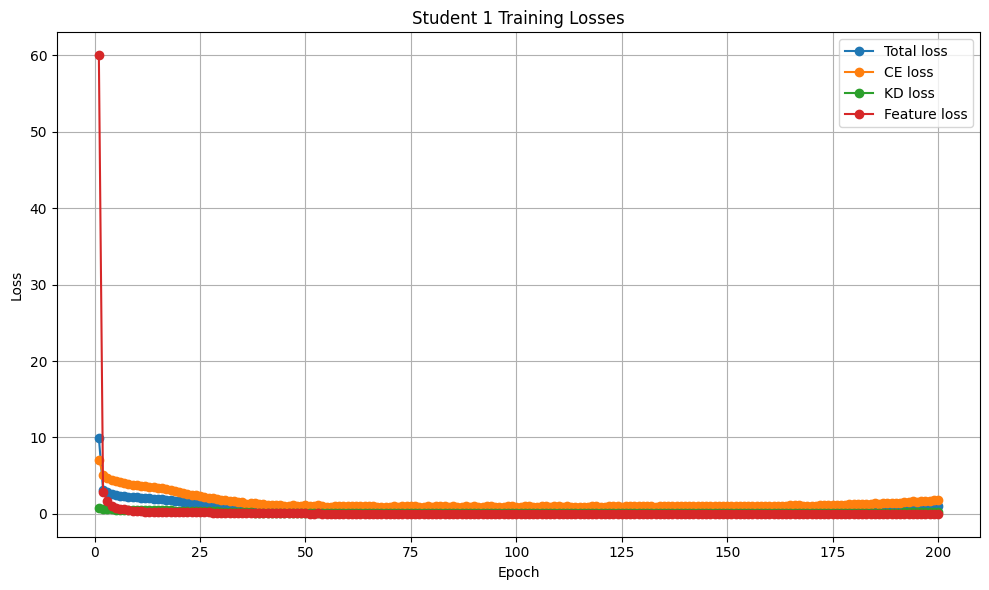

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["train_s1_loss"],
    marker="o",
    label="Total loss"
)

plt.plot(
    df["epoch"],
    df["train_s1_ce"],
    marker="o",
    label="CE loss"
)

plt.plot(
    df["epoch"],
    df["train_s1_kd"],
    marker="o",
    label="KD loss"
)

plt.plot(
    df["epoch"],
    df["train_s1_feature"],
    marker="o",
    label="Feature loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student 1 Training Losses")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

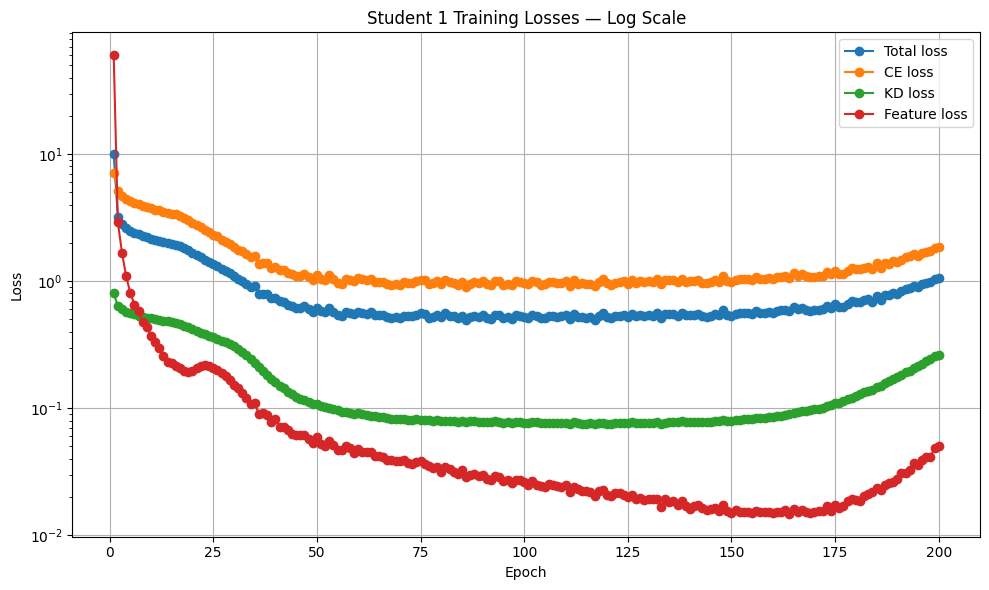

In [4]:
plt.figure(figsize=(10, 6))

plt.plot(df["epoch"], df["train_s1_loss"], marker="o", label="Total loss")
plt.plot(df["epoch"], df["train_s1_ce"], marker="o", label="CE loss")
plt.plot(df["epoch"], df["train_s1_kd"], marker="o", label="KD loss")
plt.plot(df["epoch"], df["train_s1_feature"], marker="o", label="Feature loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Student 1 Training Losses — Log Scale")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

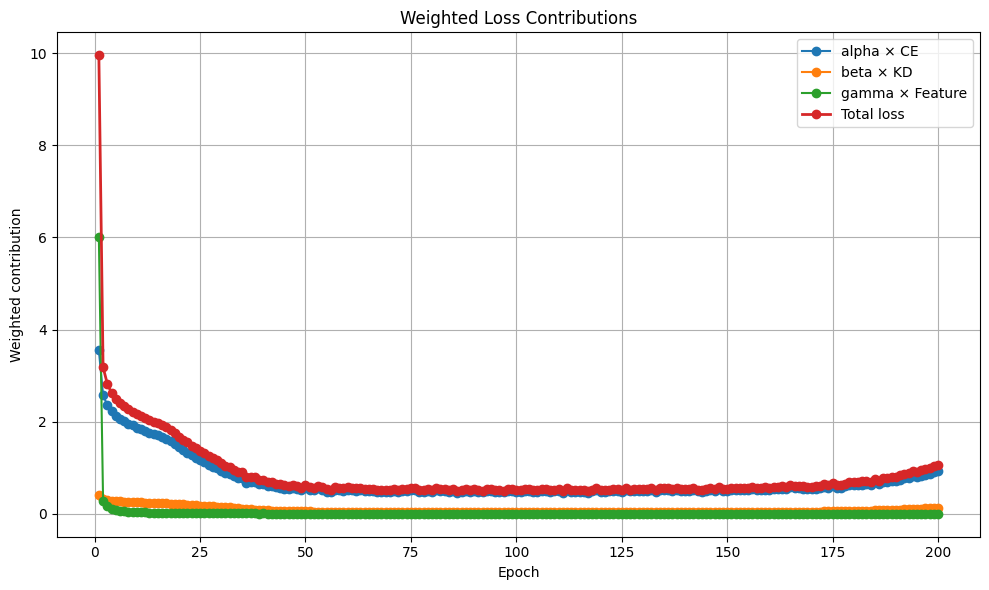

In [5]:
df["weighted_ce"] = df["alpha"] * df["train_s1_ce"]
df["weighted_kd"] = df["beta"] * df["train_s1_kd"]
df["weighted_feature"] = df["gamma"] * df["train_s1_feature"]

plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["weighted_ce"],
    marker="o",
    label="alpha × CE"
)

plt.plot(
    df["epoch"],
    df["weighted_kd"],
    marker="o",
    label="beta × KD"
)

plt.plot(
    df["epoch"],
    df["weighted_feature"],
    marker="o",
    label="gamma × Feature"
)

plt.plot(
    df["epoch"],
    df["train_s1_loss"],
    marker="o",
    linewidth=2,
    label="Total loss"
)

plt.xlabel("Epoch")
plt.ylabel("Weighted contribution")
plt.title("Weighted Loss Contributions")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

In [6]:
plt.savefig(
    "results/student1_training_losses.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [7]:
calculated_total = (
    df["alpha"] * df["train_s1_ce"]
    + df["beta"] * df["train_s1_kd"]
    + df["gamma"] * df["train_s1_feature"]
)

print(
    pd.DataFrame({
        "epoch": df["epoch"],
        "saved_total": df["train_s1_loss"],
        "calculated_total": calculated_total,
    })
)

     epoch  saved_total  calculated_total
0        1     9.955450          9.955450
1        2     3.183115          3.183115
2        3     2.826113          2.826113
3        4     2.624113          2.624113
4        5     2.493360          2.493360
..     ...          ...               ...
195    196     0.945475          0.945475
196    197     0.969514          0.969514
197    198     0.988530          0.988530
198    199     1.042215          1.042215
199    200     1.058290          1.058290

[200 rows x 3 columns]


## LoRA

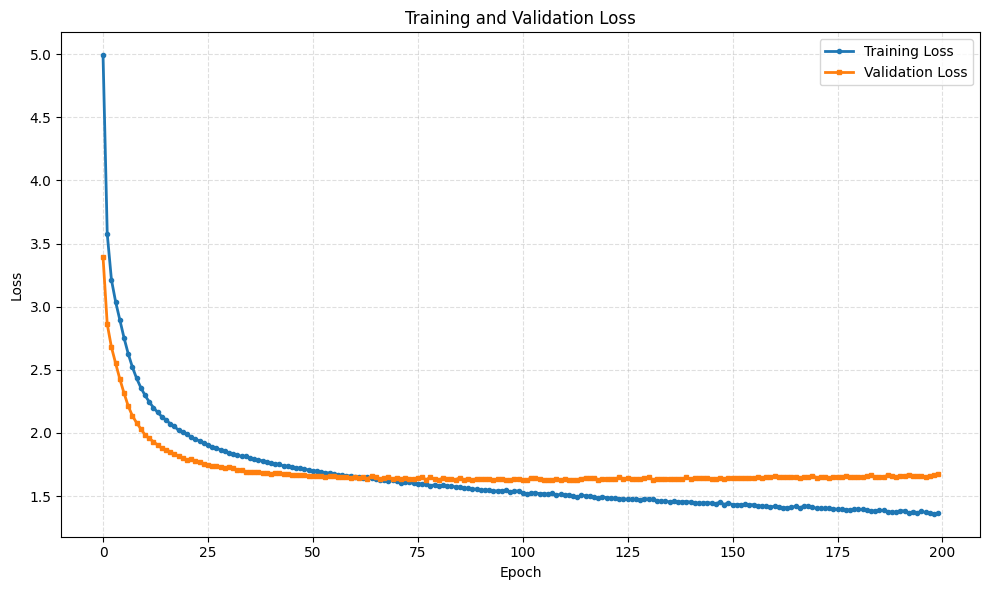

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

csv_path = "results/lora/results.csv"
# Read CSV
df = pd.read_csv(csv_path)

# Ensure columns are numeric
df["epoch"] = pd.to_numeric(df["epoch"])
df["loss"] = pd.to_numeric(df["loss"])
df["val_loss"] = pd.to_numeric(df["val_loss"])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df["epoch"],
    df["loss"],
    linewidth=2,
    marker="o",
    markersize=3,
    label="Training Loss"
)

ax.plot(
    df["epoch"],
    df["val_loss"],
    linewidth=2,
    marker="s",
    markersize=3,
    label="Validation Loss"
)

ax.set_title("Training and Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

# Display only a reasonable number of epoch labels
ax.xaxis.set_major_locator(MaxNLocator(nbins=10, integer=True))

# Grid only for major ticks
ax.grid(True, which="major", linestyle="--", alpha=0.4)

ax.legend()
fig.tight_layout()

plt.savefig(
    "training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()